In [1]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import pearsonr

# plot setting
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6.5

plt.rcParams['axes.titlesize'] = 6.5
plt.rcParams['axes.labelsize'] = 6.5
plt.rcParams['axes.labelpad'] = 2
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.75

plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['xtick.labelsize'] = 6.5
plt.rcParams['ytick.labelsize'] = 6.5
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['xtick.major.pad'] = 2
plt.rcParams['ytick.major.pad'] = 2

# get current workdir
current_path = os.getcwd()

### Scale BrIS RT into 0-100 to generate BrIS iRT

In [2]:
# scale BrIS RT into iRT
library = pd.read_csv('C:/Users/chenxin/Desktop/BrIS_project/source_data/01_BrIS_library.csv')
BrIS_RT = list(library['RT'])
zero_point_index = 0
zero_point = BrIS_RT[zero_point_index]
max_value = max(BrIS_RT)
a = 100 / (max_value - zero_point)
BrIS_iRT = [a * (rt - zero_point) for rt in BrIS_RT]
a = pd.DataFrame(data = {'RT':BrIS_RT, 'iRT':BrIS_iRT}, index = [f'BrIS-{i}' for i in range(1, 10)])
a

,RT,iRT
BrIS-1,12.1165,0.000000
BrIS-2,15.5729,23.940599
BrIS-3,16.9629,33.568371
BrIS-4,18.5791,44.762907
BrIS-5,20.3957,57.345505
BrIS-6,22.4872,71.832186
BrIS-7,23.9436,81.919875
BrIS-8,25.6237,93.557012
BrIS-9,26.5539,100.000000


### process background peptides identified from tims1, tims2 and exploris480

In [5]:
def process_bpep_results(bpep_file, NA_rates = 0.5):
    df = pd.read_csv(bpep_file)
    df = df.drop_duplicates(subset = ['PEP.StrippedSequence'], keep = 'first').copy()
    df = df.set_index('PEP.StrippedSequence')
    bpep_RT = df[[col for col in df.columns if 'RT' in col]]
    bpep_RT.columns = [f'S{i:02d}' for i in range(1, bpep_RT.shape[1]+1)]
    bpep_RT = bpep_RT.apply(pd.to_numeric, errors = 'coerce')
    # delete peptides with >50% NA and impute NA with median  
    bpep_NA_rates = bpep_RT.isna().mean(axis = 1)
    bpep_RT = bpep_RT[bpep_NA_rates <= NA_rates].copy()
    bpep_RT_filled = bpep_RT.copy()
    for peptide in bpep_RT_filled.index:
        RT_across_samples = bpep_RT_filled.loc[peptide]
        if RT_across_samples.isna().any():
            median_value = RT_across_samples.median()
            bpep_RT_filled.loc[peptide] = RT_across_samples.fillna(median_value)
    return bpep_RT_filled
tims1_bpep_RT_filled = process_bpep_results('C:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure4-8_plasma_BrIS_iRT_samples_on_TIMS1_results.csv')
tims2_bpep_RT_filled = process_bpep_results('C:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure4-8_plasma_BrIS_iRT_samples_on_TIMS2_results.csv')
exploris480_bpep_RT_filled = process_bpep_results('C:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure4-8_plasma_BrIS_iRT_samples_on_E480_results.csv')

### overlap of background peptides: tims1 and tims2, tims1 and exploris480

In [7]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2(set1, set2, label1, label2, color1, color2):
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    overlap = len(set1 & set2)
    plt.figure(figsize = (2.0, 1.7))
    v = venn2(subsets = (1, 1, 1), set_labels = (label1, label2))
    v.get_label_by_id('10').set_text(f'{only1}') 
    v.get_label_by_id('01').set_text(f'{only2}') 
    v.get_label_by_id('11').set_text(f'{overlap}')
    for p_id in ['10', '01', '11']:
        patch = v.get_patch_by_id(p_id)
        if patch:
            patch.set_color('none')
            patch.set_alpha(1.0)
    c = venn2_circles(subsets = (1, 1, 1), linewidth = 0.5, alpha = 1.0)
    c[0].set_edgecolor(color1) 
    c[1].set_edgecolor(color2) 
    for text in v.set_labels:
        if text: 
            text.set_fontsize(6.5)
            text.set_y(-0.5)
    for text in v.subset_labels:
        if text: 
            text.set_fontsize(6.5)
    plt.show()

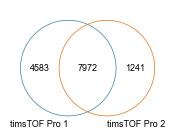

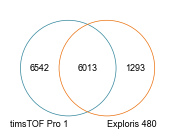

In [8]:
tims1_peptides = set(tims1_bpep_RT_filled.index)
tims2_peptides = set(tims2_bpep_RT_filled.index)
exploris480_peptides = set(exploris480_bpep_RT_filled.index)

plot_venn2(tims1_peptides, tims2_peptides, 'timsTOF Pro 1', 'timsTOF Pro 2', '#31859B', '#EA700D')
plot_venn2(tims1_peptides, exploris480_peptides, 'timsTOF Pro 1', 'Exploris 480', '#31859B', '#EA700D')

## Polynomial Regression Fitting

In [9]:
PR = {'LR':1}

### Fit BrIS iRT vs. BrIS RT (tims1, MS1)

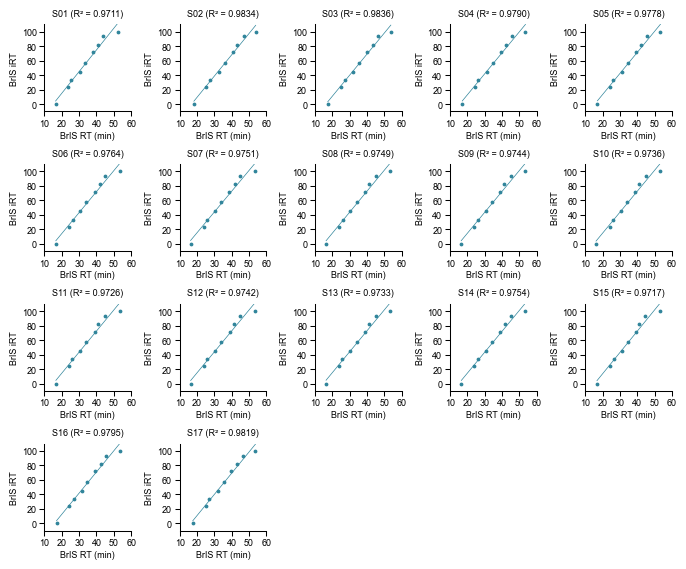

In [17]:
tims1_BrIS_RT_file = 'C:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure4_plasma_BrIS_iRT_samples_on_TIMS1_BrIS_RT.csv'
tims1_BrIS_RT = pd.read_csv(tims1_BrIS_RT_file, index_col = 0)
tims1_fit_results = {}
for sample in tims1_BrIS_RT.columns:
    BrIS_RT_array = tims1_BrIS_RT[sample].values
    BrIS_iRT_array = np.array(BrIS_iRT)
    x = np.array(BrIS_RT_array).reshape(-1, 1)
    y = BrIS_iRT_array
    # Generate smooth x values for plotting fit curve
    x_fit = np.linspace(min(BrIS_RT_array), max(BrIS_RT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': BrIS_RT_array,
            'iRT': BrIS_iRT_array
        }
    tims1_fit_results[sample] = sample_results

# Plot fit results
# width = 1.37, height = 1.42
fig, axes = plt.subplots(4, 5, figsize=(6.85, 5.68))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(tims1_fit_results):
    ax = axes[i]
    BrIS_RT_array = tims1_fit_results[sample][model_name]['RT']
    BrIS_iRT_array = tims1_fit_results[sample][model_name]['iRT']
    ax.scatter(BrIS_RT_array, BrIS_iRT_array, color = color, alpha = 1.0, s = 3)
    x_fit = tims1_fit_results[sample][model_name]['x_fit']
    y_fit = tims1_fit_results[sample][model_name]['y_fit']
    r2 = tims1_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(10, 60)
    ax.set_ylim(-10, 110)
    ax.set_xticks([10, 20, 30, 40, 50, 60])
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('BrIS RT (min)')
    ax.set_ylabel('BrIS iRT')
    ax.set_title(f'{sample} (R² = {tims1_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(tims1_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad = 1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure4/Supplementary_Figure4_{model_name}_fit_BrIS_iRT_vs_RT_TIMS1.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### Fit BrIS RT (tims2, MS1) vs. BrIS iRT

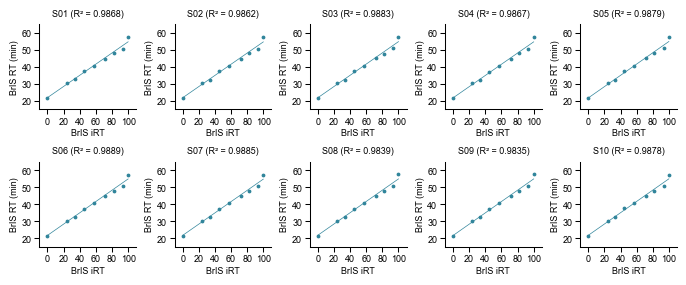

In [18]:
tims2_BrIS_RT_file = 'c:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure6a_plasma_BrIS_iRT_samples_on_TIMS2_BrIS_RT.csv'
tims2_BrIS_RT = pd.read_csv(tims2_BrIS_RT_file, index_col=0)
tims2_fit_results = {}
for sample in tims2_BrIS_RT.columns:
    BrIS_RT_array = tims2_BrIS_RT[sample].values
    BrIS_iRT_array = np.array(BrIS_iRT)
    x = BrIS_iRT_array.reshape(-1, 1)  # iRT as x (independent variable)
    y = np.array(BrIS_RT_array)         # RT as y (dependent variable)
    # Generate smooth x values for plotting
    x_fit = np.linspace(min(BrIS_iRT_array), max(BrIS_iRT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': BrIS_RT_array,
            'iRT': BrIS_iRT_array
        }
    tims2_fit_results[sample] = sample_results

# Plot fit results
fig, axes = plt.subplots(2, 5, figsize=(6.85, 2.84))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(tims2_fit_results):
    ax = axes[i]
    BrIS_RT_array = tims2_fit_results[sample][model_name]['RT']
    BrIS_iRT_array = tims2_fit_results[sample][model_name]['iRT']
    ax.scatter(BrIS_iRT_array, BrIS_RT_array, color = color, alpha = 1.0, s = 3)
    x_fit = tims2_fit_results[sample][model_name]['x_fit']
    y_fit = tims2_fit_results[sample][model_name]['y_fit']
    r2 = tims2_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(-10, 110)
    ax.set_ylim(15, 65)
    ax.set_yticks([20, 30, 40, 50, 60])
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('BrIS RT (min)')
    ax.set_xlabel('BrIS iRT')
    ax.set_title(f'{sample} (R² = {tims2_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(tims2_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure6/Supplementary_Figure6a_{model_name}_fit_BrIS_RT_vs_iRT_TIMS2.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### Fit BrIS RT (exploris480, MS1) vs. BrIS iRT

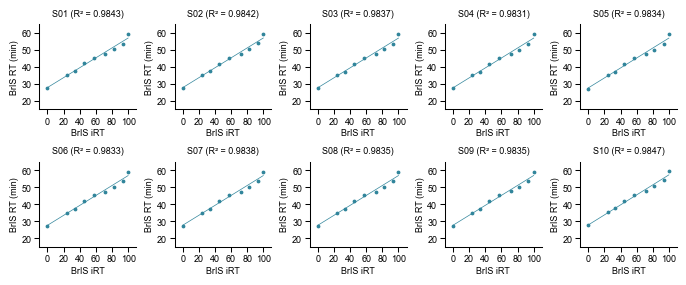

In [19]:
exploris480_BrIS_RT_file = 'c:/Users/chenxin/Desktop/BrIS_project/source_data/Supplementary_Figure6b_plasma_BrIS_iRT_samples_on_E480_BrIS_RT.csv'
exploris480_BrIS_RT = pd.read_csv(exploris480_BrIS_RT_file, index_col=0)
exploris480_fit_results = {}
for sample in exploris480_BrIS_RT.columns:
    BrIS_RT_array = exploris480_BrIS_RT[sample].values
    BrIS_iRT_array = np.array(BrIS_iRT)
    x = BrIS_iRT_array.reshape(-1, 1)  # iRT as x (independent variable)
    y = np.array(BrIS_RT_array)         # RT as y (dependent variable)
    # Generate smooth x values for plotting
    x_fit = np.linspace(min(BrIS_iRT_array), max(BrIS_iRT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': BrIS_RT_array,
            'iRT': BrIS_iRT_array
        }    
    exploris480_fit_results[sample] = sample_results

# Plot fit results
fig, axes = plt.subplots(2, 5, figsize=(6.85, 2.84))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(exploris480_fit_results):
    ax = axes[i]
    BrIS_RT_array = exploris480_fit_results[sample][model_name]['RT']
    BrIS_iRT_array = exploris480_fit_results[sample][model_name]['iRT']
    ax.scatter(BrIS_iRT_array, BrIS_RT_array, color = color, alpha = 1.0, s = 3)
    x_fit = exploris480_fit_results[sample][model_name]['x_fit']
    y_fit = exploris480_fit_results[sample][model_name]['y_fit']
    r2 = exploris480_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(-10, 110)
    ax.set_ylim(15, 65)
    ax.set_yticks([20, 30, 40, 50, 60])
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('BrIS RT (min)')
    ax.set_xlabel('BrIS iRT')
    ax.set_title(f'{sample} (R² = {exploris480_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(exploris480_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure6/Supplementary_Figure6b_{model_name}_fit_BrIS_RT_vs_iRT_E480.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### predict iRT of common peptides between tims1 and tims2 based on fitted curve of BrIS iRT vs RT on tims1

In [20]:
tims1_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = list(tims1_peptides), columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

In [21]:
plasma_peptide_iRT = tims1_peptides_iRT['LR']
plasma_peptide_iRT.to_csv('C:/Users/chenxin/Desktop/plasma_peptides_iRT_based_on_BrIS_peptides.csv')

In [22]:
tims1_tims2_peptides = list(tims1_peptides & tims2_peptides)
tims1_tims2_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = tims1_tims2_peptides, columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_tims2_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_tims2_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

### predict iRT of common peptides between tims1 and exploris480 based on fitted curve of BrIS iRT vs RT on tims1

In [23]:
tims1_exploris480_peptides = list(tims1_peptides & exploris480_peptides)
tims1_exploris480_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = tims1_exploris480_peptides, columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_exploris480_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_exploris480_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

### predict RT of tims1_tims2_peptides based on fitted curve of BrIS RT vs iRT on tims2

In [24]:
predicted_tims2_bpep_RT = {}
for model_name in PR:
    model_predicted_RT = pd.DataFrame(index=tims1_tims2_peptides, columns=tims2_bpep_RT_filled.columns[0:-1])
    for sample in tims2_bpep_RT_filled.columns[0:-1]:
        model = tims2_fit_results[sample][model_name]['model']
        for peptide in tims1_tims2_peptides:
            irt = tims1_tims2_peptides_iRT[model_name].loc[peptide, 'iRT']  # 使用对应模型的iRT
            if not pd.isna(irt):
                model_predicted_RT.loc[peptide, sample] = model.predict(np.array([[irt]]))[0]
    predicted_tims2_bpep_RT_median = pd.DataFrame({'predicted_RT': model_predicted_RT.median(axis=1)})
    predicted_tims2_bpep_RT[model_name] = predicted_tims2_bpep_RT_median

# combine experimental and predicted RT of background peptides for all models
tims2_bpep_RT_median = pd.DataFrame({'RT': tims2_bpep_RT_filled.median(axis=1)})
tims2_results = {}
for model_name in PR:
    result = pd.concat([tims2_bpep_RT_median, predicted_tims2_bpep_RT[model_name]], axis=1)
    result = result.dropna(subset=['predicted_RT'])
    tims2_results[model_name] = result

### predict RT of tims1_exploris480_peptides based on fitted curve of BrIS RT vs iRT on exploris480

In [25]:
# predict exploris480 bpep RT for all models
predicted_exploris480_bpep_RT = {}
for model_name in PR:
    model_predicted_RT = pd.DataFrame(index=tims1_exploris480_peptides, columns=exploris480_bpep_RT_filled.columns)
    for sample in exploris480_bpep_RT_filled.columns:
        model = exploris480_fit_results[sample][model_name]['model']
        for peptide in tims1_exploris480_peptides:
            irt = tims1_exploris480_peptides_iRT[model_name].loc[peptide, 'iRT']  # 使用对应模型的iRT
            if not pd.isna(irt):
                model_predicted_RT.loc[peptide, sample] = model.predict(np.array([[irt]]))[0]
    predicted_exploris480_bpep_RT_median = pd.DataFrame({'predicted_RT': model_predicted_RT.median(axis=1)})
    predicted_exploris480_bpep_RT[model_name] = predicted_exploris480_bpep_RT_median

# combine experimental and predicted RT of background peptides for all models
exploris480_bpep_RT_median = pd.DataFrame({'RT': exploris480_bpep_RT_filled.median(axis=1)})
exploris480_results = {}
for model_name in PR:
    result = pd.concat([exploris480_bpep_RT_median, predicted_exploris480_bpep_RT[model_name]], axis=1)
    result = result.dropna(subset=['predicted_RT'])
    exploris480_results[model_name] = result

### plot figure: predicted RT vs experimental RT of background peptides

In [26]:
from sklearn.metrics import r2_score
def plot_scatter(results, PR, label, instrument, color, filename):
    for model_name in PR:
        x = results[model_name]['RT'].values
        y = results[model_name]['predicted_RT'].values
        r2 = r2_score(x, y)
        fig, ax = plt.subplots(figsize=(1.53, 1.6))
        scatter = ax.scatter(x, y, alpha = 1.0, s = 8, color = color, edgecolors = 'white', linewidth = 0.02)
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], '--', alpha = 1.0, linewidth = 0.75, color = "black")
        ax.set_xlim(0, 65) 
        ax.set_ylim(0, 65)
        ax.set_xticks([0,10,20,30,40,50,60])
        ax.set_yticks([0,10,20,30,40,50,60])
        ax.set_xlabel('Experimental RT (min)') 
        ax.set_ylabel('Calibrated RT (min)')
        ax.set_title(instrument)
        textstr = f'R^2 = {r2:.4f}\nn = {len(x):,}'
        props = dict(boxstyle = 'round', facecolor = 'none', edgecolor = 'none', linewidth = 0)
        ax.text(0.05, 0.95, textstr, transform = ax.transAxes, fontsize = 6.5, verticalalignment = 'top', bbox=props)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout(pad = 0)
        plt.savefig(filename)
        plt.show()

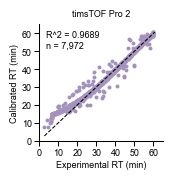

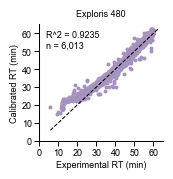

In [27]:
plot_scatter(tims2_results, PR, 'tims2', 'timsTOF Pro 2', '#A391BD',
            f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure8/Supplementary_Figure8c_LR_calibrated_RT_vs_experimental_RT_TIMS2.pdf')
plot_scatter(exploris480_results, PR, '480', 'Exploris 480', '#A391BD',
            f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure8/Supplementary_Figure8d_LR_calibrated_RT_vs_experimental_RT_E480.pdf')